# This notebook runs the quantitative analysis
Please provide the right configuration and run the notebook through to the end

In [1]:
import logging
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import yaml

from functools import partial
from logging.handlers import RotatingFileHandler
from IPython.display import Audio
from jsonschema import validate, ValidationError
from scipy.io.wavfile import write

from esc_audio_dataset import ESCAudioDataset, LABEL_MAP, REVERSE_LABEL_MAP
from bcos.modules.bcosconv2d import BcosConv2d
from config.config_validation_template import CONFIG_TEMPLATE
from custom_logger_formatter import CustomLoggerFormatter
from main import DATASET_MAPPING
from resnet_bcos import make_resnet18, make_resnet34, make_resnet50
from resnet_18_baseline import BaselineResNet
from tune import TUNABLE_PARAMS

import quant_analysis_utils as q_utils


c:\Users\joris\miniconda3\envs\INFOMHCML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0. Config & setup

In [2]:
EXPERIMENT_DIR = r"output\12-06-2026--10-41" # change directory to the specific experiment

BEST_MODEL_DIR = r"job_0" # folder containing .pt model, relative from `EXPERIMENT_DIR`

DEVICE = "cuda" # use if CUDA or ROCm

In [3]:
# Initialise Logger.
def _make_stream_handler(level: int) -> logging.StreamHandler:
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(level)
    ch.setFormatter(CustomLoggerFormatter())
    return ch

level: int=logging.DEBUG
logger = logging.getLogger("test logger")
logger.setLevel(level)
logger.propagate = False  
ch = _make_stream_handler(level)
logger.addHandler(ch)
f_ch = RotatingFileHandler(f"{EXPERIMENT_DIR}/quantitative_analysis.log")
f_ch.setLevel(level)
f_ch.setFormatter(
    logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )
)
logger.addHandler(f_ch)

logger.info(f"This file logs the testing process.")

2026-06-12 12:12:09,712 - test logger - INFO - This file logs the testing process. (1909239882.py:23)


In [4]:
# validate the provided config file.
with open(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/run_config.yml", 'r') as stream:
    CONFIG = yaml.safe_load(stream)

# Get the general config settings from the main yaml
with open(f"{EXPERIMENT_DIR}/config.yml", 'r') as stream:
    general_config = yaml.safe_load(stream)

CONFIG["general"] = general_config["general"]

try:
    validate(general_config, CONFIG_TEMPLATE)
except ValidationError as e:
    raise ValidationError(
        "\x1b[31;1mA validation error occurred in the config file" \
        f": {e.message}\x1b[0m"
    ) from e

for tunable_param in TUNABLE_PARAMS.keys():
    if type(CONFIG[tunable_param]) == list:
        CONFIG[tunable_param] = CONFIG[tunable_param][0]

logger.info("config: {CONFIG}")

2026-06-12 12:12:10,106 - test logger - INFO - config: {CONFIG} (3916436664.py:23)


### 1. Load data


In [5]:
dataset = ESCAudioDataset(
    data_dirs=DATASET_MAPPING["dirs"],
    folds=DATASET_MAPPING["train_folds"],
    csv_path=DATASET_MAPPING["csv_path"],
    target_sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_fft=CONFIG["n_fft"],
    hop_length=CONFIG["hop_length"],
    n_mels=CONFIG["n_mels"],
    top_db=CONFIG["top_db"],
)
logger.debug(f"Dataset size: {len(dataset)}")
logger.debug(f"Shape of first x element: {dataset[0][0].shape}")
logger.debug(f"First y element: {dataset[0][1]}")
test_data = ESCAudioDataset(
    data_dirs=DATASET_MAPPING["dirs"],
    folds=DATASET_MAPPING["test_folds"],
    csv_path=DATASET_MAPPING["csv_path"],
    target_sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_fft=CONFIG["n_fft"],
    hop_length=CONFIG["hop_length"],
    n_mels=CONFIG["n_mels"],
    top_db=CONFIG["top_db"],
)
logger.debug(f"Test dataset size: {len(test_data)}")

# Normalise
logger.debug("Fitting normalisation.")
dataset.fit_normalisation(list(range(len(dataset))))
test_data.mean = dataset.mean
test_data.std = dataset.std
logger.debug(
    "Normalisation fitted: "
    f"mean={dataset.mean}, std={dataset.std}"
)

2026-06-12 12:12:11,083 - test logger - DEBUG - Dataset size: 320 (715433220.py:12)
2026-06-12 12:12:11,094 - test logger - DEBUG - Shape of first x element: torch.Size([1, 128, 216]) (715433220.py:13)
2026-06-12 12:12:11,098 - test logger - DEBUG - First y element: 0 (715433220.py:14)
2026-06-12 12:12:11,137 - test logger - DEBUG - Test dataset size: 80 (715433220.py:26)
2026-06-12 12:12:11,139 - test logger - DEBUG - Fitting normalisation. (715433220.py:29)
2026-06-12 12:12:12,115 - test logger - DEBUG - Normalisation fitted: mean=-13.597201347351074, std=21.57600975036621 (715433220.py:33)


### 2. Load model

In [6]:
models = {
    "resnet18_bcos": (
        make_resnet18, {
            "logger": logger,
            "num_classes": dataset.get_n_classes(),
            "in_chans" : 1,
            "small_inputs": CONFIG["model_params"].get("small_inputs", True),
            "conv_layer": partial(BcosConv2d, b=CONFIG["b"], max_out=2),
        }
    ),
    "resnet34_bcos": (
        make_resnet34, {
            "logger": logger,
            "num_classes": dataset.get_n_classes(),
            "in_chans" : 1,
            "small_inputs": CONFIG["model_params"].get("small_inputs", True),
            "conv_layer": partial(BcosConv2d, b=CONFIG["b"], max_out=2),
        }
    ),
    "resnet50_bcos": (
        make_resnet50, {
            "logger": logger,
            "num_classes": dataset.get_n_classes(),
            "in_chans" : 1,
            "small_inputs": CONFIG["model_params"].get("small_inputs", True),
            "conv_layer": partial(BcosConv2d, b=CONFIG["b"], max_out=2),
        }
    ),
    "resnet18_baseline": (
        lambda **kwargs: BaselineResNet(kwargs["num_classes"]),
        {"logger": logger, "num_classes": dataset.get_n_classes()}
    )   
}
model = None
for name, (cls, kwargs) in models.items():
    if CONFIG['model'].lower() in name:
        model = cls(**kwargs)
        break
assert model is not None, \
    f"Provided model in config does not exist ({model})."

logger.debug(f"Model:\n{model}")
logger.debug("Total number of parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

model = model.to(DEVICE)


2026-06-12 12:12:12,352 - test logger - DEBUG - Model:
EnhancedResNet(
  (conv1): BcosConv2d(
    B=2, max_out=2,
    (linear): NormedConv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (bn1): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True, bias=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (bn1): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True, bias=False)
      (conv2): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (bn2): DetachablePositionNorm2dNoBias((64,), eps=1e-05, elementwise_affine=True, bias=False)
    )
    (1): BasicBlock(
      (conv1): BcosConv2d(
        B=2, max_out=2,
        (linear): NormedConv2d(64, 128, kern

In [7]:
model_file_path = [entry for entry in os.listdir(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}") if entry.endswith(".pth")][0]

state_dict = torch.load(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/{model_file_path}", weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

### 3. Grid pointing game

In [ ]:
train_grid_scores = q_utils.grid_pointing_game(dataset, model, DEVICE, logger, first_img_output_dir=f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/")
logger.critical(f"Grid pointing game results on train set: Total pairs evaluated: {len(train_grid_scores)} | Mean score: {train_grid_scores.mean() * 100:.5f}% | std: {train_grid_scores.std() * 100:.5f}%")

test_grid_scores = q_utils.grid_pointing_game(test_data, model, DEVICE, logger, first_img_output_dir=f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR}/")
logger.critical(f"Grid pointing game results on test set: Total pairs evaluated: {len(test_grid_scores)} | Mean score: {test_grid_scores.mean() * 100:.5f}% | std: {test_grid_scores.std() * 100:.5f}%")

2026-06-12 12:12:45,699 - test logger - DEBUG - Classes : 10 (quant_analysis_utils.py:55)
2026-06-12 12:12:45,700 - test logger - DEBUG - Rounds : 32 (320 explain calls total) (quant_analysis_utils.py:56)


Running rounds: 100%|██████████| 32/32 [01:21<00:00,  2.54s/it]

2026-06-12 12:14:07,122 - test logger - CRITICAL - Grid pointing game results on train set: Total pairs evaluated: 320 | Mean score: 38.77645% | std: 11.62422% (680396041.py:2)
2026-06-12 12:14:07,123 - test logger - DEBUG - Classes : 10 (quant_analysis_utils.py:55)
2026-06-12 12:14:07,124 - test logger - DEBUG - Rounds : 8 (80 explain calls total) (quant_analysis_utils.py:56)



Running rounds: 100%|██████████| 8/8 [00:20<00:00,  2.57s/it]

2026-06-12 12:14:27,708 - test logger - CRITICAL - Grid pointing game results on test set: Total pairs evaluated: 80 | Mean score: 32.86172% | std: 11.32468% (680396041.py:5)


2026-06-12 11:46:59,201 - test logger - WARNING - torch.Size([1, 1, 128, 432]) (1545369254.py:13)


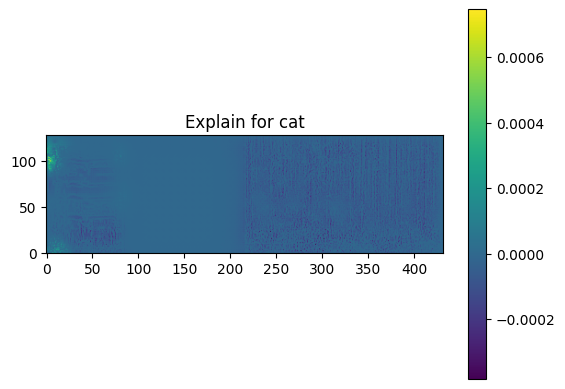

In [11]:
CAT_IMG = dataset[42][0]
CAT_LABEL = dataset[42][1]
DOG_IMG = dataset[12][0]
DOG_LABEL = dataset[12][1]

x = torch.cat([CAT_IMG, DOG_IMG], dim=-1)
x = x.unsqueeze(0).to(DEVICE).requires_grad_()
x_wav = torch.cat([
    dataset.load_waveform(42),
    dataset.load_waveform(12)
], dim=-1).to(DEVICE)

logger.warning(x.shape)

model.eval()
with torch.enable_grad():
    expl_out_cat = model.explain(x, idx=LABEL_MAP["dog"])
    plt.imshow(expl_out_cat["contribution_map"].detach().squeeze(0).squeeze(0).cpu(), origin="lower")
    plt.title(f"Explain for cat")
    plt.colorbar()
    plt.show()


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].imshow(expl_out_cat["explanation"], origin="lower", cmap="magma")
xmin, xmax = ax[0].get_xlim()
center = (xmin + xmax) / 2
ax[0].axvline(center, color="white")
ax[0].set_title(f"Prediction: cat")

ax[1].imshow(expl_out_dog["explanation"], origin="lower", cmap="magma")
ax[1].axvline(center, color="white")
ax[1].set_title(f"Prediction: dog")

plt.tight_layout()
plt.show()


In [ ]:
explanation_cat = expl_out_cat["explanation"].squeeze() * x.detach().cpu().numpy().squeeze()
explanation_cat = (explanation_cat - explanation_cat.min()) / (explanation_cat.max() - explanation_cat.min() + 1e-8) # normalize to [0, 1]

plt.imshow(explanation_cat, origin="lower")
plt.title(f"Prediction: cat")
plt.show()


In [ ]:
explanation_cat = expl_out_cat["contribution_map"].detach().cpu().squeeze()# * x.detach().cpu().numpy().squeeze()
explanation_cat = (explanation_cat - explanation_cat.min()) / (explanation_cat.max() - explanation_cat.min() + 1e-8) # normalize to [0, 1]

plt.imshow(explanation_cat, origin="lower")
plt.title(f"Prediction: cat")
plt.show()


### Baseline ResNet Explanations

### 0. Config & setup


In [ ]:
EXPERIMENT_DIR = r"output\11-06-2026--10-27" # change directory to the specific experiment

BEST_MODEL_DIR_RN = r"job_1" # folder containing .pt model, relative from `EXPERIMENT_DIR`

DEVICE = "cuda" # use if CUDA or ROCm

In [ ]:
# validate the provided config file.
with open(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR_RN}/run_config.yml", 'r') as stream:
    CONFIG = yaml.safe_load(stream)

# Get the general config settings from the main yaml
with open(f"{EXPERIMENT_DIR}/config.yml", 'r') as stream:
    general_config = yaml.safe_load(stream)

CONFIG["general"] = general_config["general"]

try:
    validate(general_config, CONFIG_TEMPLATE)
except ValidationError as e:
    raise ValidationError(
        "\x1b[31;1mA validation error occurred in the config file" \
        f": {e.message}\x1b[0m"
    ) from e

for tunable_param in TUNABLE_PARAMS.keys():
    if type(CONFIG[tunable_param]) == list:
        CONFIG[tunable_param] = CONFIG[tunable_param][0]

logger.info("config: {CONFIG}")

### Load Model

In [ ]:
models_baseline = {
    "resnet18_baseline": (
            lambda **kwargs: BaselineResNet(kwargs["num_classes"]),
            {"logger": logger, "num_classes": dataset.get_n_classes()}
    )   
    }
model_bl = None
for name, (cls, kwargs) in models_baseline.items():
    if CONFIG['model'].lower() in name:
        model_bl = cls(**kwargs)
        break
assert model is not None, \
    f"Provided model in config does not exist ({model_bl})."

logger.debug(f"Model:\n{model_bl}")
logger.debug("Total number of parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

model_bl = model_bl.to(DEVICE)

In [ ]:
model_file_path = [entry for entry in os.listdir(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR_RN}") if entry.endswith(".pth")][0]

state_dict = torch.load(f"{EXPERIMENT_DIR}/{BEST_MODEL_DIR_RN}/{model_file_path}", weights_only=True)
model_bl.load_state_dict(state_dict)

### Initializing GradCAM

In [ ]:
# Load baseline model
num_classes = dataset.get_n_classes()
model_baseline = BaselineResNet(num_classes=num_classes).to(DEVICE)

checkpoint_folder = os.path.join(EXPERIMENT_DIR, BEST_MODEL_DIR_RN)

checkpoint_path = [
    os.path.join(checkpoint_folder, f)
    for f in os.listdir(checkpoint_folder)
    if f.endswith(".pth")
][0]

state_dict = torch.load(checkpoint_path, weights_only=True)

model_baseline.load_state_dict(state_dict)
model_baseline.eval()

# Select example
index = 5
x = dataset[index][0].unsqueeze(0).to(DEVICE)
x_vis = x.squeeze().detach().cpu().numpy()
x_vis = (x_vis - x_vis.min()) / (x_vis.max() - x_vis.min() + 1e-8)

# Grad-CAM
cam_extractor = GradCAM(model_baseline.model, target_layer="layer4")
y_hat = model_baseline.model(x)
pred_class = y_hat.argmax(dim=1).item()

cams = cam_extractor(pred_class, y_hat)[0]
cams_resized = F.interpolate(
    cams.unsqueeze(0),
    size=x.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(x_vis, origin="lower", cmap="magma")
plt.title(f"Original Spectrogram (True: {REVERSE_LABEL_MAP[dataset[index][1]]})")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Normalized amplitude")

plt.subplot(1, 2, 2)
plt.imshow(x_vis, origin="lower", cmap="magma")
plt.imshow(
    cams_resized.squeeze().cpu().detach().numpy(),
    origin="lower",
    cmap="jet",
    alpha=0.5
)
plt.title(f"Grad-CAM Overlay (Pred: {REVERSE_LABEL_MAP[pred_class]})")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Grad-CAM intensity")

plt.tight_layout()
plt.show()

### Audio masking with Grad-CAM explanations for baseline ResNet

In [ ]:
# Load baseline model using the current job folder
num_classes = dataset.get_n_classes()
model_baseline = BaselineResNet(num_classes=num_classes).to(DEVICE)

checkpoint_folder = os.path.join(EXPERIMENT_DIR, BEST_MODEL_DIR_RN)

checkpoint_path = [
    os.path.join(checkpoint_folder, f)
    for f in os.listdir(checkpoint_folder)
    if f.endswith(".pth")
][0]

state_dict = torch.load(checkpoint_path, weights_only=True)
model_baseline.load_state_dict(state_dict)
model_baseline.eval()

print(f"Loaded baseline checkpoint from: {checkpoint_path}")

CAT_IDX = 4
DOG_IDX = 407

CAT_IMG = dataset[CAT_IDX][0]
DOG_IMG = dataset[DOG_IDX][0]

x = torch.cat([CAT_IMG, DOG_IMG], dim=-1).unsqueeze(0).to(DEVICE)
x_wav = torch.cat(
    [dataset.load_waveform(CAT_IDX), dataset.load_waveform(DOG_IDX)],
    dim=-1
).to(DEVICE)


x_vis = x.squeeze().detach().cpu().numpy()
x_vis = (x_vis - x_vis.min()) / (x_vis.max() - x_vis.min() + 1e-8)

cam_extractor = GradCAM(model_baseline.model, target_layer="layer4")

cat_idx = LABEL_MAP["cat"]
y_hat_cat = model_baseline.model(x)
cams_cat = cam_extractor(cat_idx, y_hat_cat)[0]
cams_cat_resized = F.interpolate(
    cams_cat.unsqueeze(0),
    size=x.shape[-2:],
    mode="bilinear",
    align_corners=False
)
cams_cat_resized = (
    cams_cat_resized - cams_cat_resized.min()
) / (cams_cat_resized.max() - cams_cat_resized.min() + 1e-8)

dog_idx = LABEL_MAP["dog"]
y_hat_dog = model_baseline.model(x)
cams_dog = cam_extractor(dog_idx, y_hat_dog)[0]
cams_dog_resized = F.interpolate(
    cams_dog.unsqueeze(0),
    size=x.shape[-2:],
    mode="bilinear",
    align_corners=False
)
cams_dog_resized = (
    cams_dog_resized - cams_dog_resized.min()
) / (cams_dog_resized.max() - cams_dog_resized.min() + 1e-8)


def apply_gradcam_mask(cam_map, wav):
    stft = STFT()
    stft_spec = stft.forward(wav).squeeze(0)

    cam_2d = cam_map.squeeze(0).squeeze(0)

    cam_resized = F.interpolate(
        cam_2d.unsqueeze(0).unsqueeze(0),
        size=stft_spec.shape,
        mode="bilinear",
        align_corners=False
    ).squeeze(0).squeeze(0)

    mask = (cam_resized - cam_resized.min()) / (
        cam_resized.max() - cam_resized.min() + 1e-8
    )
    mask = mask ** 2.5

    mag = stft_spec.abs()
    phase = stft_spec.angle()

    threshold = torch.quantile(mask, 0.9)
    binary_mask = (mask >= threshold).float()

    mag_weighted = mag * binary_mask
    alpha = 3
    mag_masked = mag_weighted * (1.0 + alpha * mask)
    spec_masked = mag_masked * torch.exp(1j * phase)

    wav_out = stft.inverse(spec_masked.unsqueeze(0))
    return wav_out


expl_out_wav_cat = apply_gradcam_mask(cams_cat_resized, x_wav)
expl_out_wav_dog = apply_gradcam_mask(cams_dog_resized, x_wav)

write("original_DOG_CAT.wav", CONFIG["sample_rate"], x_wav.squeeze().cpu().numpy())
write("explanation_CAT_gradcam.wav", CONFIG["sample_rate"], expl_out_wav_cat.squeeze().cpu().numpy())
write("explanation_DOG_gradcam.wav", CONFIG["sample_rate"], expl_out_wav_dog.squeeze().cpu().numpy())

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(x_vis, origin="lower", aspect="auto", cmap="magma")
plt.imshow(
    cams_cat_resized.squeeze().cpu().detach().numpy(),
    origin="lower",
    aspect="auto",
    cmap="jet",
    alpha=0.5
)
plt.title("Grad-CAM Overlay (Cat prediction)")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Importance")

plt.subplot(1, 2, 2)
plt.imshow(x_vis, origin="lower", aspect="auto", cmap="magma")
plt.imshow(
    cams_dog_resized.squeeze().cpu().detach().numpy(),
    origin="lower",
    aspect="auto",
    cmap="jet",
    alpha=0.5
)
plt.title("Grad-CAM Overlay (Dog prediction)")
plt.xlabel("Time")
plt.ylabel("Mel Bin")
plt.colorbar(label="Importance")

plt.tight_layout()
plt.show()

print("Original CAT + DOG audio:")
display(Audio(x_wav.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))

print("Grad-CAM explanation for CAT:")
display(Audio(expl_out_wav_cat.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))

print("Grad-CAM explanation for DOG:")
display(Audio(expl_out_wav_dog.squeeze().cpu().numpy(), rate=CONFIG["sample_rate"]))